# Combined Market Value Model

This notebook combines the prepared FIFA feature set from `model_ready.csv` with Transfermarkt-derived features from `transfermarkt_cleaned.csv`.

Goal: build the highest-accuracy player market value model we can get from the two sources while keeping the merge transparent, reproducible, and leakage-aware.

In [15]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
})
sns.set_palette(['#1a73e8', '#e8710a', '#34a853', '#ea4335', '#9334e6', '#00bcd4'])


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'ML').exists():
            return candidate
    raise FileNotFoundError('Could not locate repository root from current notebook path.')


repo_root = find_repo_root(Path.cwd())
model_ready_path = repo_root / 'ML' / 'data' / 'features' / 'model_ready.csv'
transfermarkt_path = repo_root / 'ML' / 'data' / 'processed' / 'transfermarkt_cleaned.csv'

model_ready = pd.read_csv(model_ready_path)
transfermarkt = pd.read_csv(transfermarkt_path)

print('model_ready path:', model_ready_path)
print('transfermarkt path:', transfermarkt_path)
print('model_ready shape:', model_ready.shape)
print('transfermarkt shape:', transfermarkt.shape)
print()
print('model_ready columns:')
print(model_ready.columns.tolist())
print()
print('transfermarkt columns:')
print(transfermarkt.columns.tolist())

model_ready path: /home/adham/Desktop/DEPI-ML-PROJECT/ML/data/features/model_ready.csv
transfermarkt path: /home/adham/Desktop/DEPI-ML-PROJECT/ML/data/processed/transfermarkt_cleaned.csv
model_ready shape: (20621, 19)
transfermarkt shape: (39224, 49)

model_ready columns:
['age', 'overall', 'potential', 'age_potential_gap', 'is_at_peak', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'position_group_GK', 'position_group_DEF', 'position_group_MID', 'position_group_ATT', 'log_value', 'short_name', 'market_value_eur', 'value_per_rating']

transfermarkt columns:
['player_id', 'last_name', 'name', 'last_season', 'current_club_id', 'country_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'international_caps', 'international_goals', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur', 'age', 'log_market_value', 'contract_years_

In [6]:
def normalize_text(value: object) -> str:
    text = '' if pd.isna(value) else str(value)
    text = text.strip().lower()
    text = re.sub(r'[^a-z0-9\s]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def canonical_name_key(value: object) -> str:
    text = normalize_text(value)
    if not text:
        return ''
    parts = text.split()
    if len(parts) == 1:
        return parts[0]
    return f"{parts[0][0]} {parts[-1]}"


fifa = model_ready.copy()
tm = transfermarkt.copy()
use_shared_player_id = 'player_id' in fifa.columns and 'player_id' in tm.columns


def build_merge_key(df: pd.DataFrame, source: str) -> pd.Series:
    if use_shared_player_id and 'player_id' in df.columns:
        return df['player_id'].astype(str).str.strip().str.lower().radd('id_')
    if source == 'fifa' and 'short_name' in df.columns:
        return df['short_name'].map(canonical_name_key)
    if source == 'transfermarkt' and 'name' in df.columns:
        return df['name'].map(canonical_name_key)
    raise KeyError(f'Could not build merge key for {source}.')


fifa['merge_key'] = build_merge_key(fifa, 'fifa')
tm['merge_key'] = build_merge_key(tm, 'transfermarkt')

shared_keys = set(fifa['merge_key']).intersection(set(tm['merge_key']))
print('Shared merge keys:', len(shared_keys))
print('FIFA rows with a match:', fifa['merge_key'].isin(shared_keys).mean().round(3))
print('Transfermarkt rows with a match:', tm['merge_key'].isin(shared_keys).mean().round(3))

transfermarkt_keep = [
    'merge_key',
    'age',
    'sub_position',
    'position',
    'foot',
    'height_in_cm',
    'international_caps',
    'international_goals',
    'contract_years_left',
    'total_games',
    'total_goals',
    'total_assists',
    'total_yellow',
    'total_red',
    'total_minutes',
    'avg_minutes',
    'goals_per_game',
    'assists_per_game',
    'caps_per_year',
    'goals_per_cap',
    'assists_per_cap',
    'games_per_year',
    'is_top_club',
    'club_strength_rank',
    'league_tier',
    'current_club_domestic_competition_id',
]
transfermarkt_keep = [col for col in transfermarkt_keep if col in tm.columns]

# Prefix Transfermarkt features so the sources stay readable after the join.
tm_features = tm[transfermarkt_keep].copy()
tm_features = tm_features.rename(columns={col: f'tm_{col}' for col in tm_features.columns if col != 'merge_key'})
tm_features = tm_features.rename(columns={'merge_key': 'tm_merge_key'})
tm_features = tm_features.drop_duplicates(subset=['tm_merge_key'])

combined = fifa.merge(tm_features, left_on='merge_key', right_on='tm_merge_key', how='inner')
combined = combined.drop(columns=['merge_key', 'tm_merge_key'])

print('Combined shape:', combined.shape)
print('Combined columns:', combined.columns.tolist())
print('Target nulls:', combined['market_value_eur'].isna().sum())
print('Duplicate rows:', combined.duplicated().sum())

Shared merge keys: 10979
FIFA rows with a match: 0.623
Transfermarkt rows with a match: 0.366
Combined shape: (12844, 37)
Combined columns: ['age', 'overall', 'potential', 'age_potential_gap', 'is_at_peak', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'position_group_GK', 'position_group_DEF', 'position_group_MID', 'position_group_ATT', 'log_value', 'short_name', 'market_value_eur', 'value_per_rating', 'tm_age', 'tm_sub_position', 'tm_position', 'tm_foot', 'tm_height_in_cm', 'tm_international_caps', 'tm_international_goals', 'tm_contract_years_left', 'tm_total_games', 'tm_total_goals', 'tm_total_assists', 'tm_total_yellow', 'tm_total_red', 'tm_total_minutes', 'tm_avg_minutes', 'tm_goals_per_game', 'tm_assists_per_game', 'tm_current_club_domestic_competition_id']
Target nulls: 0
Duplicate rows: 0


## Merge Validation and Modeling

The next cells verify the merged table, remove leakage-prone columns, and compare several sklearn regressors on the same train/test split.

In [10]:
target_col = 'log_value'
X = combined.copy()
X = X.drop(columns=[c for c in ['short_name', 'market_value_eur', 'value_per_rating', 'tm_age'] if c in X.columns])
y = X.pop(target_col)
price_reference = combined['market_value_eur']

numeric_cols = [col for col in X.columns if pd.api.types.is_numeric_dtype(X[col])]
categorical_cols = [col for col in X.columns if col not in numeric_cols]

try:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', one_hot),
        ]), categorical_cols),
    ],
    remainder='drop',
)

X_train, X_test, y_train, y_test, price_train, price_test = train_test_split(
    X,
    y,
    price_reference,
    test_size=0.2,
    random_state=42,
)

candidates = {
    'random_forest': RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
    'extra_trees': ExtraTreesRegressor(
        n_estimators=600,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1,
    ),
    'hist_gb': HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=8,
        max_iter=300,
        min_samples_leaf=20,
        random_state=42,
    ),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = []
trained_pipelines = {}

for name, estimator in candidates.items():
    pipeline = Pipeline([
        ('preprocess', preprocess),
        ('model', estimator),
    ])
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'r2': 'r2',
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error',
        },
        n_jobs=-1,
        return_train_score=False,
    )
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline

    train_pred_log = pipeline.predict(X_train)
    test_pred_log = pipeline.predict(X_test)
    train_pred = np.expm1(train_pred_log)
    test_pred = np.expm1(test_pred_log)

    results.append({
        'model': name,
        'cv_r2': scores['test_r2'].mean(),
        'cv_mae_log': -scores['test_mae'].mean(),
        'cv_rmse_log': -scores['test_rmse'].mean(),
        'test_r2': r2_score(y_test, test_pred_log),
        'test_mae_log': mean_absolute_error(y_test, test_pred_log),
        'test_rmse_log': np.sqrt(mean_squared_error(y_test, test_pred_log)),
        'test_mae_eur': mean_absolute_error(price_test, test_pred),
        'test_rmse_eur': np.sqrt(mean_squared_error(price_test, test_pred)),
    })

results_df = pd.DataFrame(results).sort_values(['test_r2', 'test_mae_eur'], ascending=[False, True])
results_df

,model,cv_r2,cv_mae_log,cv_rmse_log,test_r2,test_mae_log,test_rmse_log,test_mae_eur,test_rmse_eur
2,hist_gb,0.992596,0.040554,0.099730,0.991707,0.044820,0.108504,164520.945111,541501.386441
1,extra_trees,0.991527,0.036927,0.106265,0.991582,0.036495,0.109324,129321.887677,474514.728783
0,random_forest,0.991085,0.042629,0.109565,0.991421,0.041571,0.110360,152425.231643,593488.778492


## Tune the Best Model and Inspect It

The next cells tune the strongest candidate from the initial comparison and inspect the most influential features using permutation importance.

In [13]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV

best_model_name = results_df.iloc[0]['model']
best_estimator = candidates[best_model_name]

best_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', best_estimator),
])

param_grids = {
    'random_forest': {
        'model__n_estimators': [400, 700],
        'model__max_depth': [None, 18, 28],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 0.7],
    },
    'extra_trees': {
        'model__n_estimators': [600, 900],
        'model__max_depth': [None, 18, 28],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 0.7],
    },
    'hist_gb': {
        'model__learning_rate': [0.03, 0.05, 0.08],
        'model__max_depth': [4, 6, 8],
        'model__max_iter': [250, 400],
        'model__min_samples_leaf': [10, 20, 30],
    },
}

grid = GridSearchCV(
    best_pipeline,
    param_grid=param_grids[best_model_name],
    scoring='r2',
    cv=cv,
    n_jobs=-1,
    refit=True,
)
grid.fit(X_train, y_train)

best_tuned_pipeline = grid.best_estimator_
tuned_test_pred_log = best_tuned_pipeline.predict(X_test)
tuned_test_pred = np.expm1(tuned_test_pred_log)

print('Best model from comparison:', best_model_name)
print('Best tuned params:', grid.best_params_)
print('Tuned test R2:', r2_score(y_test, tuned_test_pred_log))
print('Tuned test MAE EUR:', mean_absolute_error(price_test, tuned_test_pred))
print('Tuned test RMSE EUR:', np.sqrt(mean_squared_error(price_test, tuned_test_pred)))

importance = permutation_importance(
    best_tuned_pipeline,
    X_test,
    y_test,
    n_repeats=8,
    random_state=42,
    scoring='r2',
    n_jobs=-1,
)
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': importance.importances_mean,
}).sort_values('importance', ascending=False)
importance_df.head(20)

Best model from comparison: hist_gb
Best tuned params: {'model__learning_rate': 0.03, 'model__max_depth': 6, 'model__max_iter': 400, 'model__min_samples_leaf': 10}
Tuned test R2: 0.9919191872600985
Tuned test MAE EUR: 172577.93851125144
Tuned test RMSE EUR: 550233.5559913457


,feature,importance
1,overall,1.110318
2,potential,0.214462
0,age,0.096156
11,position_group_GK,0.009144
8,dribbling,0.002211
6,shooting,0.000964
3,age_potential_gap,0.000872
9,defending,0.000535
12,position_group_DEF,0.000288
19,tm_international_caps,0.000205


## Final Summary

The notebook ends by comparing the tuned model with the initial leaderboard and plotting the strongest features plus prediction error behavior.

           model     cv_r2  cv_mae_log  cv_rmse_log   test_r2  test_mae_log  \
2        hist_gb  0.992596    0.040554     0.099730  0.991707      0.044820   
1    extra_trees  0.991527    0.036927     0.106265  0.991582      0.036495   
0  random_forest  0.991085    0.042629     0.109565  0.991421      0.041571   

   test_rmse_log   test_mae_eur  test_rmse_eur  
2       0.108504  164520.945111  541501.386441  
1       0.109324  129321.887677  474514.728783  
0       0.110360  152425.231643  593488.778492  

                  feature  importance
1                 overall    1.110318
2               potential    0.214462
0                     age    0.096156
11      position_group_GK    0.009144
8               dribbling    0.002211
6                shooting    0.000964
3       age_potential_gap    0.000872
9               defending    0.000535
12     position_group_DEF    0.000288
19  tm_international_caps    0.000205
23         tm_total_goals    0.000091
14     position_group_ATT    0

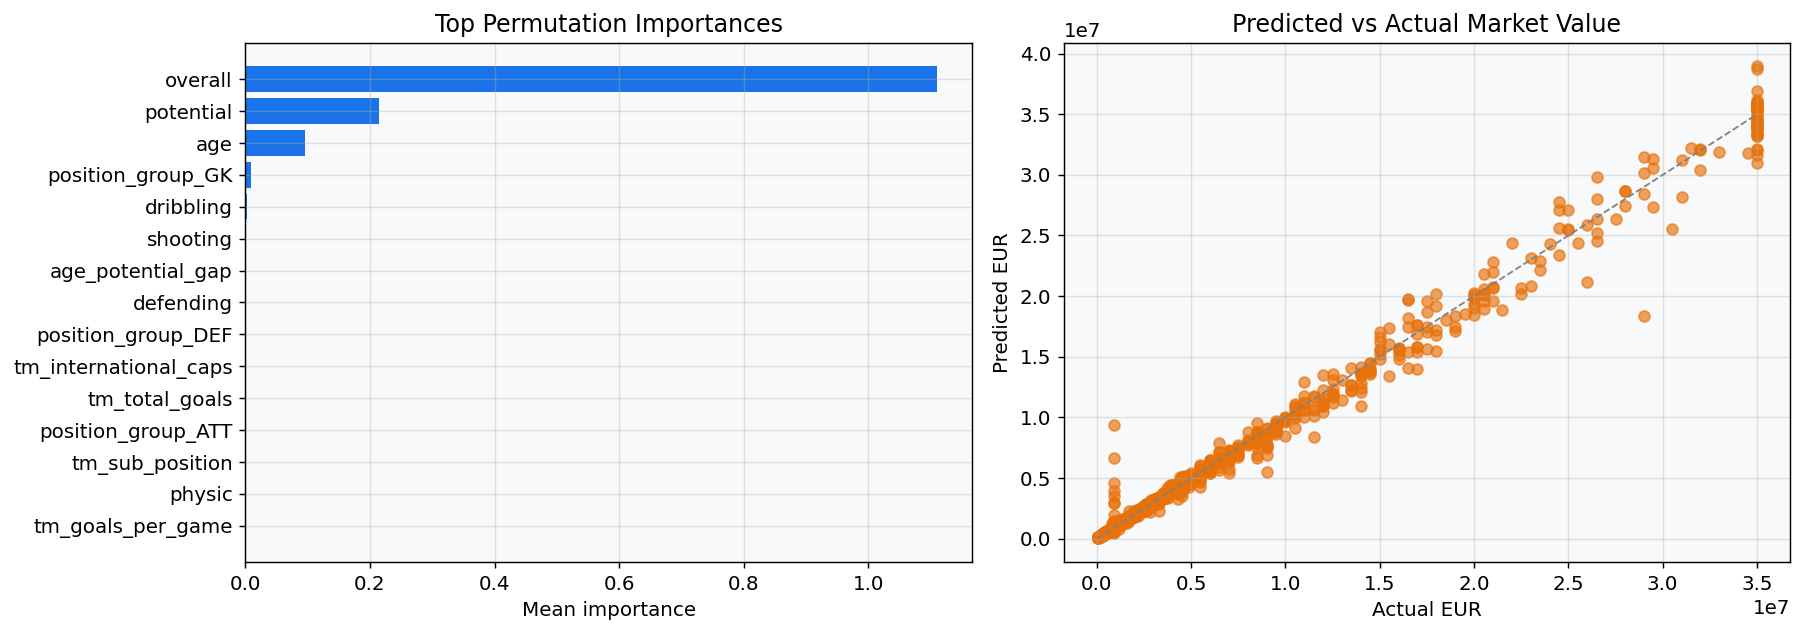

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(importance_df.head(15)['feature'][::-1], importance_df.head(15)['importance'][::-1], color='#1a73e8')
axes[0].set_title('Top Permutation Importances')
axes[0].set_xlabel('Mean importance')

axes[1].scatter(price_test, tuned_test_pred, alpha=0.65, color='#e8710a')
limit = min(price_test.max(), tuned_test_pred.max())
axes[1].plot([0, limit], [0, limit], '--', color='gray', linewidth=1)
axes[1].set_title('Predicted vs Actual Market Value')
axes[1].set_xlabel('Actual EUR')
axes[1].set_ylabel('Predicted EUR')

plt.tight_layout()

print(results_df)
print()
print(importance_df.head(20))

In [16]:
# --- Test-set evaluation: residuals, percent difference, and z-score
pred_log_test = best_tuned_pipeline.predict(X_test)
pred_eur_test = np.expm1(pred_log_test)
actual_eur_test = price_test.values

residual_eur = pred_eur_test - actual_eur_test
pct_diff = residual_eur / (actual_eur_test + 1e-9)

test_report = pd.DataFrame({
    'short_name': combined.loc[X_test.index, 'short_name'].values,
    'actual_eur': actual_eur_test,
    'predicted_eur': pred_eur_test,
    'residual_eur': residual_eur,
    'pct_diff': pct_diff,
    'age': combined.loc[X_test.index, 'age'].values,
    'overall': combined.loc[X_test.index, 'overall'].values,
})

test_report['z_pct_diff'] = (test_report['pct_diff'] - test_report['pct_diff'].mean()) / (test_report['pct_diff'].std() + 1e-12)

# Save a copy for later review
out_path = repo_root / 'ML' / 'data' / 'processed' / 'model_undervalued_report_test.csv'
test_report.to_csv(out_path, index=False)

print('Test report saved to', out_path)

print('\nTop 20 - model predicts MUCH higher than market (potentially undervalued)')
display(test_report.sort_values('pct_diff', ascending=False).head(20))

print('\nTop 20 - model predicts MUCH lower than market (potentially overvalued)')
display(test_report.sort_values('pct_diff').head(20))

Test report saved to /home/adham/Desktop/DEPI-ML-PROJECT/ML/data/processed/model_undervalued_report_test.csv

Top 20 - model predicts MUCH higher than market (potentially undervalued)


,short_name,actual_eur,predicted_eur,residual_eur,pct_diff,age,overall,z_pct_diff
2277,C. Rodríguez,925000.0,9.351756e+06,8.426756e+06,9.110007,25,76,34.872368
2058,T. Vaclík,925000.0,6.616192e+06,5.691192e+06,6.152640,33,80,23.539792
1843,Joaquín,925000.0,4.555225e+06,3.630225e+06,3.924567,40,79,15.001856
449,A. Ayew,925000.0,3.932997e+06,3.007997e+06,3.251889,32,75,12.424163
381,J. Brabec,925000.0,3.477757e+06,2.552757e+06,2.759738,29,74,10.538249
421,A. Ali,925000.0,2.926715e+06,2.001715e+06,2.164016,25,72,8.255455
2256,I. Ivušić,925000.0,2.909757e+06,1.984757e+06,2.145683,27,73,8.185203
2513,F. Helander,925000.0,1.975106e+06,1.050106e+06,1.135249,29,72,4.313240
1326,Salva Sevilla,825000.0,1.316970e+06,4.919699e+05,0.596327,38,74,2.248100
1935,D. Riznyk,925000.0,1.405183e+06,4.801832e+05,0.519117,23,68,1.952231



Top 20 - model predicts MUCH lower than market (potentially overvalued)


,short_name,actual_eur,predicted_eur,residual_eur,pct_diff,age,overall,z_pct_diff
999,S. Silva,925000.0,4.270921e+05,-4.979079e+05,-0.538279,41,70,-2.099690
1739,R. Santa Cruz,925000.0,5.414330e+05,-3.835670e+05,-0.414667,40,71,-1.626012
451,Kenedy,9000000.0,5.472420e+06,-3.527580e+06,-0.391953,26,76,-1.538974
1242,L. Modrić,29000000.0,1.835679e+07,-1.064321e+07,-0.367007,36,88,-1.443380
638,F. de Vries,925000.0,5.938812e+05,-3.311188e+05,-0.357966,27,64,-1.408736
1439,Pepe Reina,1200000.0,8.059584e+05,-3.940416e+05,-0.328368,39,77,-1.295316
1059,G. Arteaga,3300000.0,2.230304e+06,-1.069696e+06,-0.324150,23,72,-1.279154
1280,R. Cota,925000.0,6.372680e+05,-2.877320e+05,-0.311062,34,75,-1.228998
2014,M. Neuer,11500000.0,8.382485e+06,-3.117515e+06,-0.271088,36,89,-1.075821
471,D. Löfquist,230000.0,1.686720e+05,-6.132799e+04,-0.266643,35,64,-1.058788


In [17]:
# --- Full-dataset predictions (use with caution - includes training rows)
all_pred_log = best_tuned_pipeline.predict(X)
all_pred_eur = np.expm1(all_pred_log)
combined['predicted_eur'] = all_pred_eur
combined['pct_diff'] = (combined['predicted_eur'] - combined['market_value_eur']) / (combined['market_value_eur'] + 1e-9)

# Save combined with predictions
combined_out = repo_root / 'ML' / 'data' / 'features' / 'combined_with_preds.csv'
combined.to_csv(combined_out, index=False)
print('Combined predictions saved to', combined_out)

# Show top candidates from full table
display(combined[['short_name','market_value_eur','predicted_eur','pct_diff']].sort_values('pct_diff', ascending=False).head(30))

Combined predictions saved to /home/adham/Desktop/DEPI-ML-PROJECT/ML/data/features/combined_with_preds.csv


,short_name,market_value_eur,predicted_eur,pct_diff
1127,A. Vega,925000.0,2.068396e+07,21.361040
4670,H. Martín,925000.0,9.377118e+06,9.137425
2210,C. Rodríguez,925000.0,9.351756e+06,9.110007
7065,L. Chávez,925000.0,7.119961e+06,6.697256
12077,T. Vaclík,925000.0,6.616192e+06,6.152640
5319,J. Denayer,925000.0,4.795611e+06,4.184444
10319,R. Funes Mori,925000.0,4.622118e+06,3.996885
6350,Joaquín,925000.0,4.555225e+06,3.924567
8520,M. Normann,925000.0,4.321709e+06,3.672118
12729,Z. Kalmár,925000.0,4.060640e+06,3.389881


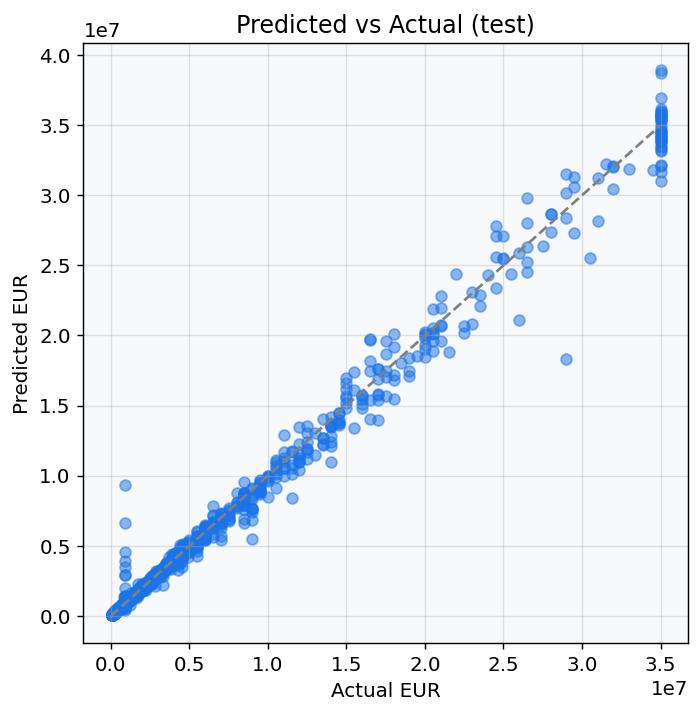

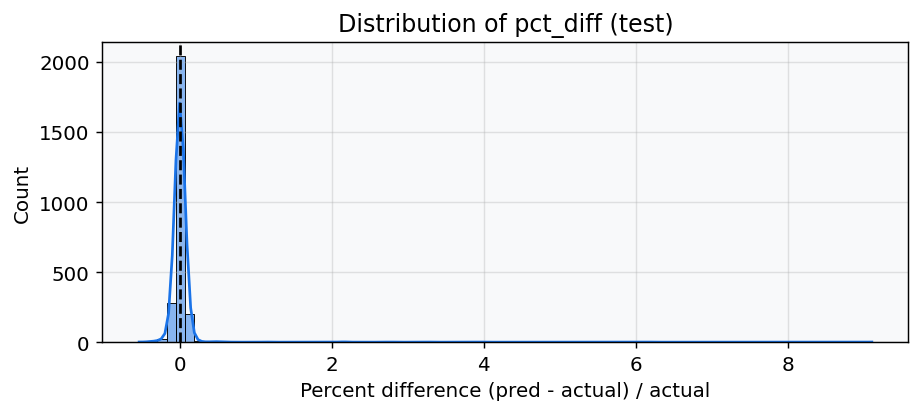

In [18]:
# --- Visualizations: Pred vs Actual and pct_diff distribution
plt.figure(figsize=(6,6))
plt.scatter(price_test, pred_eur_test, alpha=0.5)
plt.plot([0, price_test.max()], [0, price_test.max()], '--', color='gray')
plt.xlabel('Actual EUR')
plt.ylabel('Predicted EUR')
plt.title('Predicted vs Actual (test)')
plt.show()

plt.figure(figsize=(8,3))
sns.histplot(test_report['pct_diff'], bins=80, kde=True)
plt.axvline(0, color='k', linestyle='--')
plt.title('Distribution of pct_diff (test)')
plt.xlabel('Percent difference (pred - actual) / actual')
plt.show()

In [ ]:
# --- Optional: bootstrap-based uncertainty (slow). Disabled by default.
# To run: set RUN_BOOTSTRAP = True and pick n_boot <= 50 for speed.
RUN_BOOTSTRAP = False
if RUN_BOOTSTRAP:
    from sklearn.base import clone

    def bootstrap_prediction_std(pipeline, X_train, y_train, X_pred, n_boot=20, random_state=42):
        rng = np.random.RandomState(random_state)
        preds = np.zeros((n_boot, len(X_pred)))
        for i in range(n_boot):
            idx = rng.randint(0, len(X_train), len(X_train))
            p = clone(pipeline)
            p.fit(X_train.iloc[idx], y_train.iloc[idx])
            preds[i] = np.expm1(p.predict(X_pred))
        return preds.std(axis=0), preds.mean(axis=0)

    stds, means = bootstrap_prediction_std(best_tuned_pipeline, X_train, y_train, X_test, n_boot=20)
    test_report['pred_std_eur'] = stds
    test_report['pred_mean_eur'] = means
    print('Bootstrap completed; added pred_std_eur to test_report')
else:
    print('Bootstrap step skipped (RUN_BOOTSTRAP=False)')